# Mall Customer Segmentation (Part 1)
## K-Means vs Hierarchical Clustering vs DBSCAN

**Goal:** Segment mall customers by Annual Income and Spending Score, compare three clustering algorithms, and identify the best model to carry into Part 2 (Supervised Classifier).

**Dataset:** Mall Customers — 200 rows, features: CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)
**Datasource:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**Notebook flow:**
| Section | What happens |
|---|---|
| 1–4 | Imports, load data, EDA, feature scaling |
| 5 | Find optimal k (Elbow + Silhouette) |
| 6 | K-Means |
| 7 | Hierarchical Clustering |
| 8 | DBSCAN |
| 9 | Side-by-side visualisation |
| 10 | Metric comparison → pick best model |
| 11 | Cluster profiling of best model |
| 12 | Export labels for Part 2 |
| 13 | Summary |

**Dataset:** Mall Customers dataset — 200 rows, features include CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1-100).

**Datasource: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

from google.colab import drive

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

## 2. Load Data

In [5]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ML_Projects/MallCustomerSegmentation/Mall_Customers.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nGender value counts:")
print(df['Gender'].value_counts())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (200, 5)

Gender value counts:
Gender
Female    112
Male       88
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis

I first inspect data quality (nulls, dtypes) and then explore distributions and relationships between features.

In [6]:
# ── Data quality check ──
print("=== Null Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
df.info()

=== Null Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 3.1 Summary Statistics

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 3.2 Distribution Plots

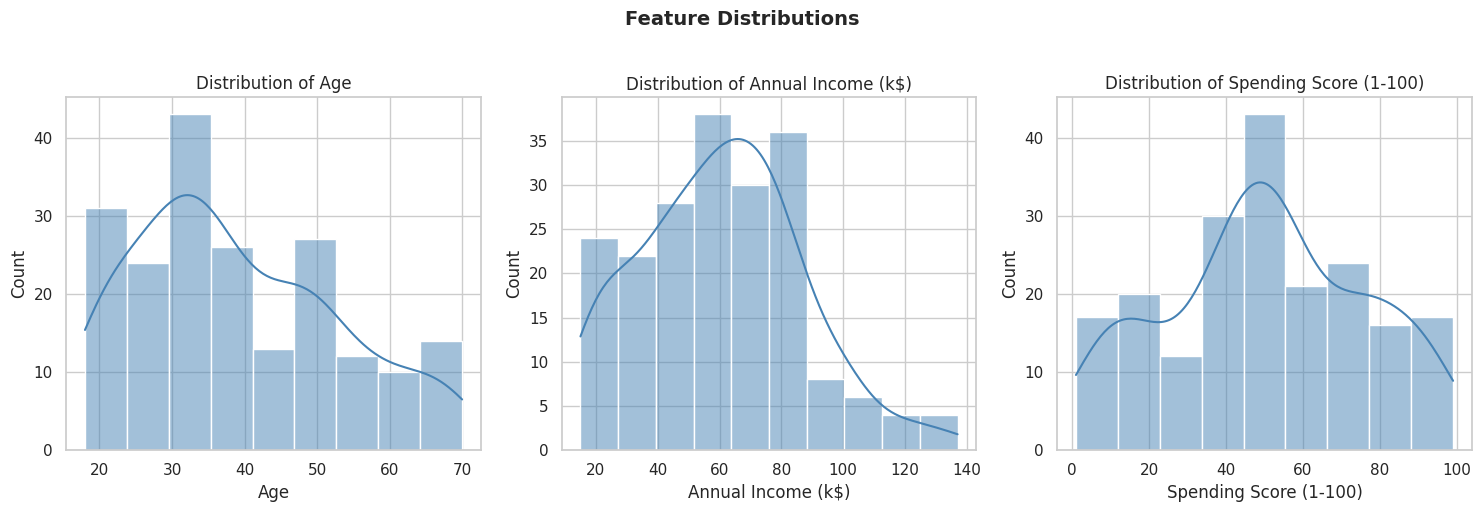

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3  Boxplots — Outlier Detection

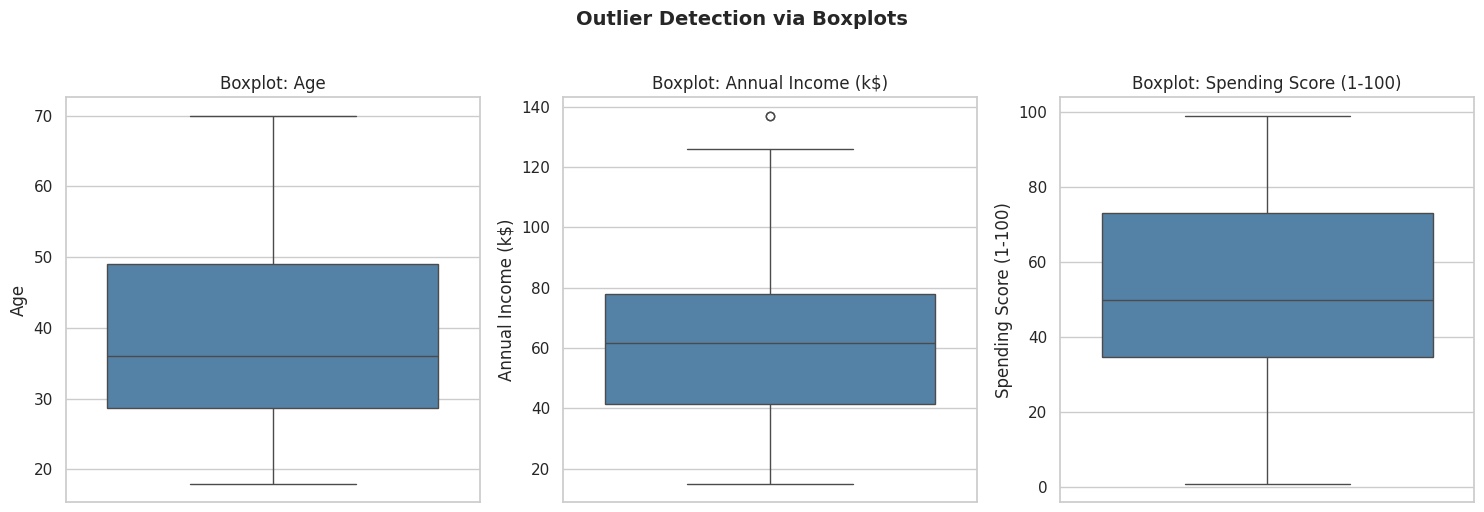

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot: {col}')

plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Pairplot
Plots every feature pair in a grid. Key insight: **Income × Spending Score** shows the clearest blob separation → confirms these are the right features to cluster on.

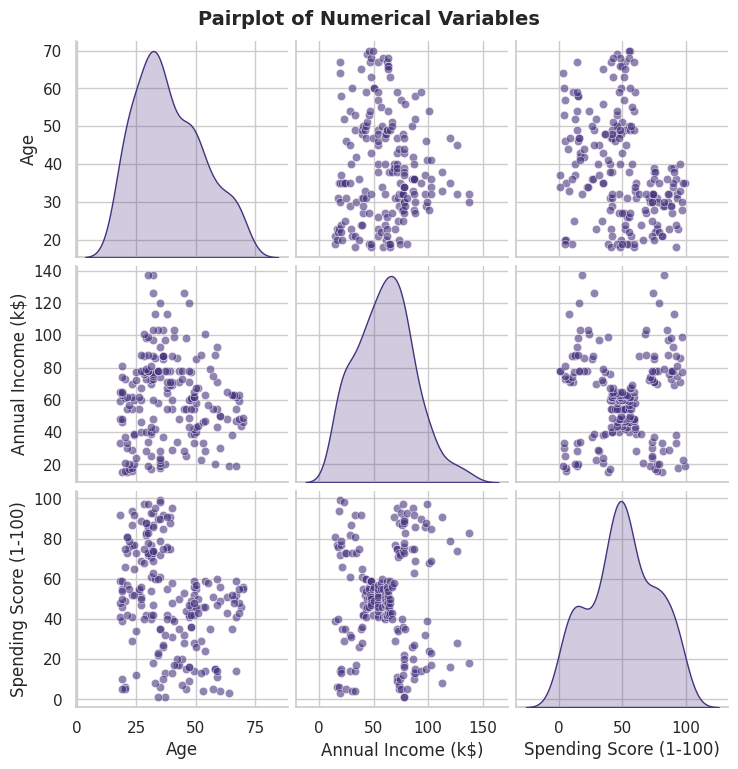

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns.drop('CustomerID', errors='ignore')
sns.pairplot(df[numerical_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Numerical Variables', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Feature Selection & Scaling


Clustering on **Annual Income** and **Spending Score** — confirmed by pairplot as the most separable pair.

> ⚠️ K-Means and Hierarchical Clustering are distance-based, so scaling is essential. Without it, Income (range ~15–137k) would dominate Spending Score (range 1–100) in distance calculations. `StandardScaler` gives each feature zero mean and unit variance.

> 📝 **Why not Gender?** Including Gender encoded as 0/1 was tested and *reduced* the Silhouette Score — it added noise rather than signal, so I keep the 2-feature setup.

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature ranges:")
print(X.describe().loc[['min', 'max']])
print("\nScaled feature ranges:")
print(pd.DataFrame(X_scaled, columns=X.columns).describe().loc[['min', 'max']].round(3))

Original feature ranges:
     Annual Income (k$)  Spending Score (1-100)
min                15.0                     1.0
max               137.0                    99.0

Scaled feature ranges:
     Annual Income (k$)  Spending Score (1-100)
min              -1.739                  -1.910
max               2.918                   1.894


## 5. Finding Optimal k (Elbow + Silhouette)

Run K-Means for k = 1–10. The elbow (WCSS bend) and Silhouette peak together indicate the best k.
This k is also used for Hierarchical Clustering in Section 7.

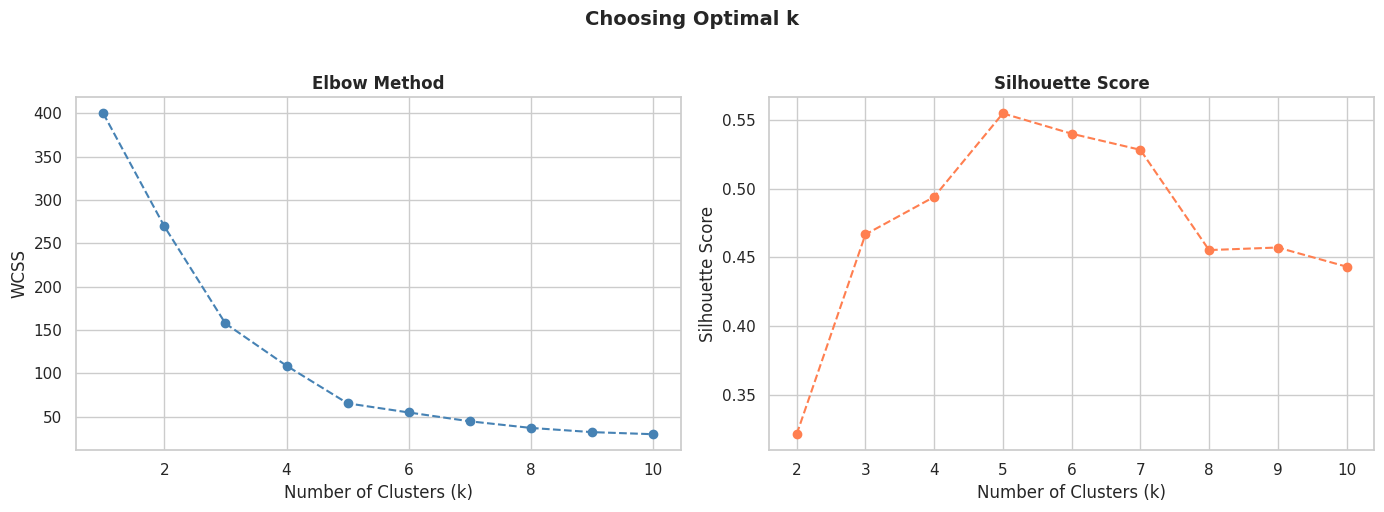

✅ Optimal k = 5  (highest Silhouette Score: 0.5547)


In [20]:
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 11), wcss, marker='o', linestyle='--', color='steelblue')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')
axes[0].grid(True)

axes[1].plot(list(k_range), sil_scores, marker='o', linestyle='--', color='coral')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.suptitle('Choosing Optimal k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

OPTIMAL_K = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"✅ Optimal k = {OPTIMAL_K}  (highest Silhouette Score: {max(sil_scores):.4f})")

## 6. K-Means Clustering

**How it works:** Randomly initialises k centroids, assigns each point to the nearest centroid, then moves centroids to the cluster mean. Repeats until stable.

**Strength:** Fast, simple, works well when clusters are roughly spherical and equal-sized.

In [21]:
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

km_sil = silhouette_score(X_scaled, kmeans_labels)
km_db  = davies_bouldin_score(X_scaled, kmeans_labels)
km_ch  = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"K-Means (k={OPTIMAL_K})")
print(f"  Silhouette Score :  {km_sil:.4f}")
print(f"  Davies-Bouldin   :  {km_db:.4f}")
print(f"  Calinski-Harabasz:  {km_ch:.2f}")
print(f"\nCluster sizes:\n{pd.Series(kmeans_labels).value_counts().sort_index().to_dict()}")

K-Means (k=5)
  Silhouette Score :  0.5547
  Davies-Bouldin   :  0.5722
  Calinski-Harabasz:  248.65

Cluster sizes:
{0: 81, 1: 39, 2: 22, 3: 35, 4: 23}


## 7. Hierarchical Clustering (Agglomerative)

**How it works:** Starts with every point as its own cluster, then repeatedly merges the two closest clusters. The result is a tree (dendrogram) we cut at a chosen height to get k clusters.

**Strength:** The dendrogram visually suggests the natural number of clusters; doesn't assume spherical shapes.

### 7.1 Dendrogram — confirm the cut point

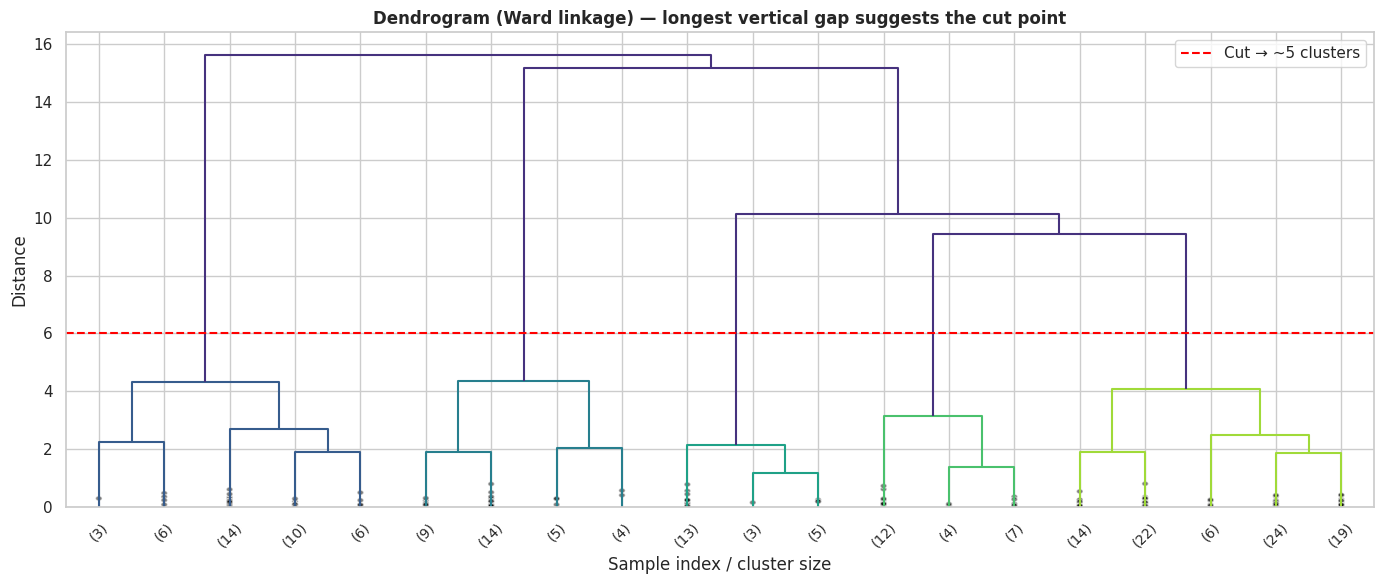

In [22]:
linked = linkage(X_scaled, method='ward')  # Ward minimises within-cluster variance

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=6
)
plt.title('Dendrogram (Ward linkage) — longest vertical gap suggests the cut point', fontweight='bold')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Distance')
plt.axhline(y=6, color='red', linestyle='--', label=f'Cut → ~{OPTIMAL_K} clusters')
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Fit Agglomerative Clustering

In [23]:
hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)
df['Hier_Cluster'] = hier_labels

hier_sil = silhouette_score(X_scaled, hier_labels)
hier_db  = davies_bouldin_score(X_scaled, hier_labels)
hier_ch  = calinski_harabasz_score(X_scaled, hier_labels)

print(f"Hierarchical Clustering (k={OPTIMAL_K}, Ward linkage)")
print(f"  Silhouette Score :  {hier_sil:.4f}")
print(f"  Davies-Bouldin   :  {hier_db:.4f}")
print(f"  Calinski-Harabasz:  {hier_ch:.2f}")
print(f"\nCluster sizes:\n{pd.Series(hier_labels).value_counts().sort_index().to_dict()}")

Hierarchical Clustering (k=5, Ward linkage)
  Silhouette Score :  0.5538
  Davies-Bouldin   :  0.5779
  Calinski-Harabasz:  244.41

Cluster sizes:
{0: 32, 1: 39, 2: 85, 3: 21, 4: 23}


## 8. DBSCAN (Density-Based Clustering)

**How it works:** Groups points in dense regions; sparse points are labelled as **noise (−1)** rather than forced into a cluster.

**Strength:** Automatically finds the number of clusters; handles irregular shapes; explicitly flags outliers.

**Two key parameters:**
- `eps` — neighbourhood radius to search for nearby points
- `min_samples` — minimum neighbours within eps to be a core point

### 8.1 k-Distance Plot — tune eps
The "knee" of this curve is a good starting eps value.

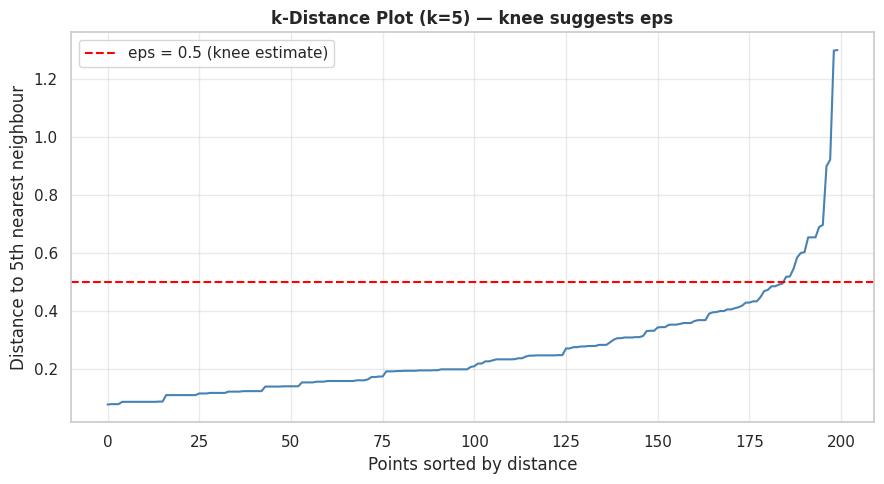

In [24]:
MIN_SAMPLES = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(distances, color='steelblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps = 0.5 (knee estimate)')
plt.title(f'k-Distance Plot (k={MIN_SAMPLES}) — knee suggests eps', fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {MIN_SAMPLES}th nearest neighbour')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 8.2 eps Sensitivity Check

In [25]:
print(f"{'eps':>6} | {'Clusters':>8} | {'Noise pts':>9} | {'Silhouette':>10}")
print("-" * 42)
for eps_val in [0.3, 0.4, 0.5, 0.6, 0.8, 1.0]:
    lbs = DBSCAN(eps=eps_val, min_samples=5).fit_predict(X_scaled)
    nc  = len(set(lbs)) - (1 if -1 in lbs else 0)
    nn  = (lbs == -1).sum()
    mask = lbs != -1
    sil = silhouette_score(X_scaled[mask], lbs[mask]) if nc >= 2 and mask.sum() > nc else float('nan')
    print(f"{eps_val:>6} | {nc:>8} | {nn:>9} | {sil:>10.4f}")

print("\nChoose the eps with the most clusters closest to OPTIMAL_K and lowest noise.")

   eps | Clusters | Noise pts | Silhouette
------------------------------------------
   0.3 |        7 |        35 |     0.5243
   0.4 |        4 |        15 |     0.4781
   0.5 |        2 |         8 |     0.3876
   0.6 |        1 |         5 |        nan
   0.8 |        1 |         0 |        nan
   1.0 |        1 |         0 |        nan

Choose the eps with the most clusters closest to OPTIMAL_K and lowest noise.


### 8.3 Fit Final DBSCAN

In [26]:
EPS = 0.5  # update based on sensitivity table above

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})")
print(f"  Clusters found : {n_dbscan_clusters}")
print(f"  Noise points   : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}% of data)")

mask = dbscan_labels != -1
if n_dbscan_clusters >= 2:
    dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_db  = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_ch  = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
    print(f"  Silhouette Score :  {dbscan_sil:.4f}  (noise excluded)")
    print(f"  Davies-Bouldin   :  {dbscan_db:.4f}")
    print(f"  Calinski-Harabasz:  {dbscan_ch:.2f}")
else:
    dbscan_sil = dbscan_db = dbscan_ch = None
    print("Too few clusters — try adjusting eps")

DBSCAN (eps=0.5, min_samples=5)
  Clusters found : 2
  Noise points   : 8 (4.0% of data)
  Silhouette Score :  0.3876  (noise excluded)
  Davies-Bouldin   :  0.7889
  Calinski-Harabasz:  85.39


## 9. Side-by-Side Visualisation

All three models on the same axes (original scale) for a fair visual comparison.

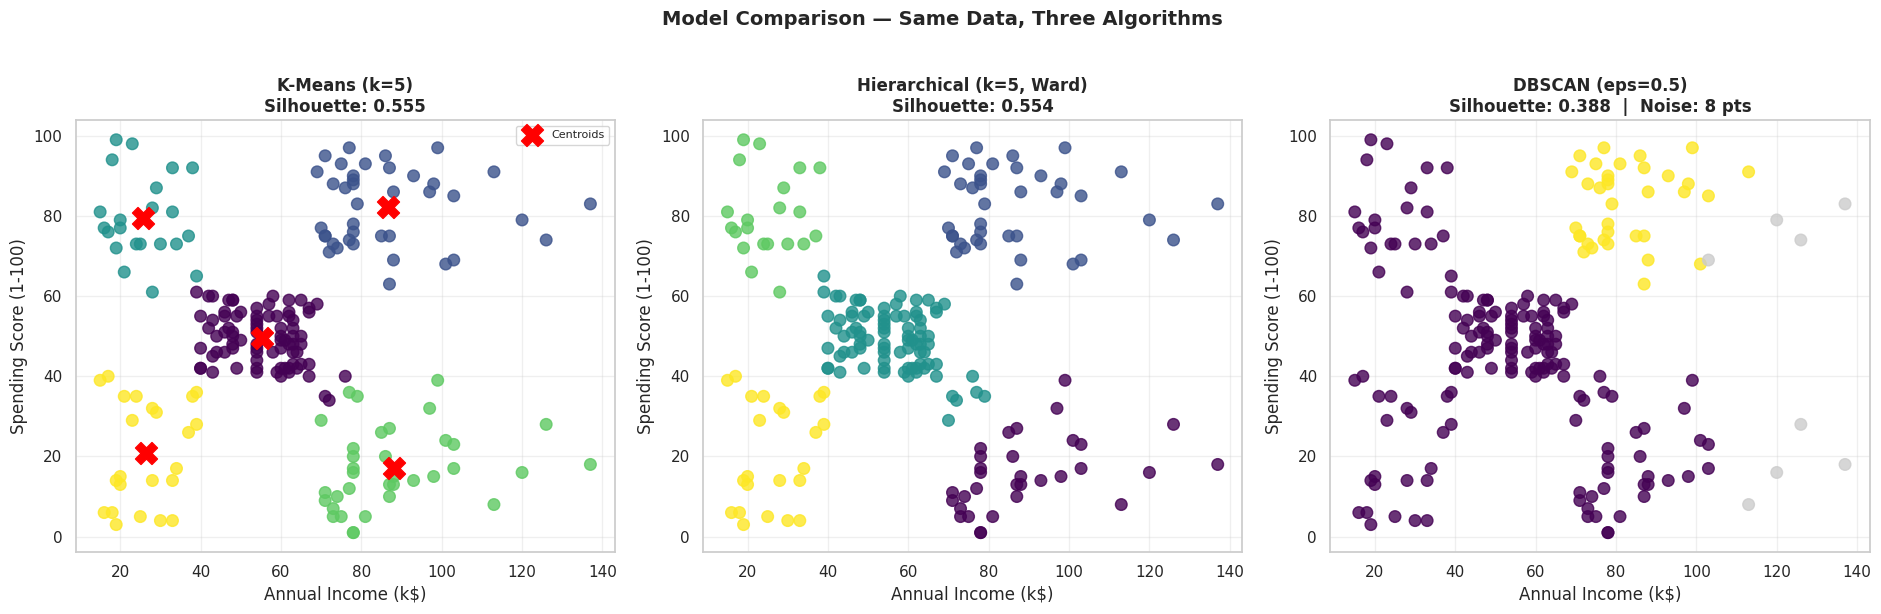

In [27]:
X_orig = scaler.inverse_transform(X_scaled)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# K-Means
axes[0].scatter(X_orig[:, 0], X_orig[:, 1], c=kmeans_labels, cmap='viridis', s=70, alpha=0.8)
axes[0].scatter(centroids_orig[:, 0], centroids_orig[:, 1], c='red', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (k={OPTIMAL_K})\nSilhouette: {km_sil:.3f}', fontweight='bold')
axes[0].legend(fontsize=8)

# Hierarchical
axes[1].scatter(X_orig[:, 0], X_orig[:, 1], c=hier_labels, cmap='viridis', s=70, alpha=0.8)
axes[1].set_title(f'Hierarchical (k={OPTIMAL_K}, Ward)\nSilhouette: {hier_sil:.3f}', fontweight='bold')

# DBSCAN — noise in grey
palette = plt.cm.viridis
max_lbl = max(l for l in dbscan_labels if l != -1) if n_dbscan_clusters > 0 else 1
colors_db = ['#cccccc' if l == -1 else palette(l / max_lbl) for l in dbscan_labels]
axes[2].scatter(X_orig[:, 0], X_orig[:, 1], c=colors_db, s=70, alpha=0.8)
sil_str = f'{dbscan_sil:.3f}' if dbscan_sil else 'N/A'
axes[2].set_title(f'DBSCAN (eps={EPS})\nSilhouette: {sil_str}  |  Noise: {n_noise} pts', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison — Same Data, Three Algorithms', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Metric Comparison — Pick the Best Model

Three metrics give a fuller picture than Silhouette alone:

| Metric | Measures | Direction |
|---|---|---|
| **Silhouette Score** | How well each point fits its own cluster vs neighbours | Higher ↑ |
| **Davies-Bouldin Index** | Ratio of within-cluster scatter to between-cluster distance | Lower ↓ |
| **Calinski-Harabasz Score** | Ratio of between-cluster to within-cluster dispersion | Higher ↑ |

The model that wins 2 or more metrics is selected as the best model for Part2.

In [32]:
results = pd.DataFrame({
    'Model'               : ['K-Means', 'Hierarchical', 'DBSCAN*'],
    'n_clusters'          : [OPTIMAL_K, OPTIMAL_K, n_dbscan_clusters],
    'Silhouette ↑'        : [km_sil,  hier_sil,  dbscan_sil  or float('nan')],
    'Davies-Bouldin ↓'    : [km_db,   hier_db,   dbscan_db   or float('nan')],
    'Calinski-Harabasz ↑' : [km_ch,   hier_ch,   dbscan_ch   or float('nan')],
}).set_index('Model').round(4)

display(results)

# Majority vote
best_sil  = results['Silhouette ↑'].idxmax()
best_db   = results['Davies-Bouldin ↓'].idxmin()
best_ch   = results['Calinski-Harabasz ↑'].idxmax()

votes = pd.Series([best_sil, best_db, best_ch]).value_counts()
BEST_MODEL = votes.idxmax()

print(f"\n  Best Silhouette     → {best_sil}")
print(f"  Best Davies-Bouldin → {best_db}")
print(f"  Best Calinski-Harabasz → {best_ch}")
print(f"\n BEST MODEL: {BEST_MODEL}")


# Map to label column
label_col_map = {'K-Means': 'KMeans_Cluster', 'Hierarchical': 'Hier_Cluster', 'DBSCAN*': 'DBSCAN_Cluster'}
BEST_LABEL_COL = label_col_map[BEST_MODEL]

,n_clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Model,,,,
K-Means,5,0.5547,0.5722,248.6493
Hierarchical,5,0.5538,0.5779,244.4103
DBSCAN*,2,0.3876,0.7889,85.3897



  Best Silhouette     → K-Means
  Best Davies-Bouldin → K-Means
  Best Calinski-Harabasz → K-Means

 BEST MODEL: K-Means


## 11. Cluster Profiling — Best Model

Summarize each cluster to translate the math into business insight.

In [33]:
profile_df = df[df[BEST_LABEL_COL] != -1].copy() if BEST_MODEL == 'DBSCAN*' else df.copy()

profile_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
profile = profile_df.groupby(BEST_LABEL_COL)[profile_cols].mean().round(1)
profile['Count'] = profile_df[BEST_LABEL_COL].value_counts().sort_index()

print(f"Cluster Profiles — {BEST_MODEL}:")
display(profile)

Cluster Profiles — K-Means:


,Age,Annual Income (k$),Spending Score (1-100),Count
KMeans_Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


## 12. Export Labelled Dataset for Part 2

Save the dataset with the best model's cluster labels as a CSV. Part 3 loads this file directly — no need to re-run clustering.

In [34]:
export_df = df[['Age', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)', BEST_LABEL_COL]].copy()
export_df = export_df.rename(columns={BEST_LABEL_COL: 'Cluster_Label'})

# Drop noise points if DBSCAN won
if BEST_MODEL == 'DBSCAN*':
    n_before = len(export_df)
    export_df = export_df[export_df['Cluster_Label'] != -1].reset_index(drop=True)
    print(f"Dropped {n_before - len(export_df)} DBSCAN noise points.")

save_path = '/content/drive/MyDrive/ML_Projects/MallCustomerSegmentation/clustered_customers.csv'
export_df.to_csv(save_path, index=False)

print(f"✅ Saved {len(export_df)} rows → {save_path}")
print(f"   Best model     : {BEST_MODEL}")
print(f"   Unique clusters: {export_df['Cluster_Label'].nunique()}")
display(export_df.head())

✅ Saved 200 rows → /content/drive/MyDrive/ML_Projects/MallCustomerSegmentation/clustered_customers.csv
   Best model     : K-Means
   Unique clusters: 5


,Age,Gender,Annual Income (k$),Spending Score (1-100),Cluster_Label
0,19,Male,15,39,4
1,21,Male,15,81,2
2,20,Female,16,6,4
3,23,Female,16,77,2
4,31,Female,17,40,4


## 13. Summary

### What I did
1. **EDA** — quality check, distributions, boxplots, pairplot → confirmed Income × Spending as best features
2. **Feature scaling** — StandardScaler applied before all clustering (critical for distance-based models)
3. **Optimal k** — Elbow + Silhouette analysis run once, shared by K-Means and Hierarchical
4. **K-Means** — fast baseline, spherical clusters, k-means++ initialisation
5. **Hierarchical** — Ward linkage dendrogram confirmed same k; no randomness
6. **DBSCAN** — k-distance plot tuned eps; auto-detected clusters and noise points
7. **Compared** — Silhouette, Davies-Bouldin, Calinski-Harabasz → majority vote picked best model
8. **Profiled** — best model's clusters described in business terms
9. **Exported** — `clustered_customers.csv` ready for Part 3

### Model characteristics recap
| Model | Needs k? | Handles noise? | Assumes shape |
|---|---|---|---|
| K-Means | ✅ Yes | ❌ No | Spherical |
| Hierarchical | ✅ Yes (via dendrogram) | ❌ No | Flexible |
| DBSCAN | ❌ No | ✅ Yes | Any shape |

### Coming up — Part 2
Train a **supervised classifier** on the winning cluster labels to predict which segment a brand new customer belongs to, using Age, Gender, Income, and Spending Score as features.